DI725 Term Project

Research Question: Does adding textual information improve remote sensing image classification performance compared to image only inputs?

Google Drive Link:https://drive.google.com/drive/folders/1f-3Tu53bY1zJ2Xg2qfjUn6oSSuXeHmv8?usp=drive_link

The goal of this project is to investigate whether textual information improves classification performance compared to image only inputs.

Ground truth labels are derived from segmentation masks. Pixel wise class distribution is used for that purpose.

A FLAVA model is used to process both image only and image+text inputs, since FLAVA is a unified multimodal transformer that can handle image, text, and combined image text data.

**1-Importing Required Libraries and Data Loading**

In this step, images, segmentation masks, and caption data are loaded from the dataset.

*   Images: RGB remote sensing images
*   Masks: Pixel wise segmentation maps
*   Captions: Textual descriptions generated by different models

Using GitHub was not feasible due to the very large size of the datasets. Therefore, Google Drive storage was used, and the data for the model was retrieved from this storage.


In [1]:
# Install the required Hugging Face libraries for FLAVA, model utilities, and evaluation
!pip install -q transformers datasets accelerate evaluate

import os
import random
import numpy as np
import pandas as pd

from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt


from transformers import FlavaProcessor, FlavaModel




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Base project path
base_path = "/content/drive/MyDrive/DI725_Transformer/TermProject"

# Subfolders
images_path = os.path.join(base_path, "images")
masks_path = os.path.join(base_path, "masks")
captions_path = os.path.join(base_path, "captions.csv")

print("Images path:", images_path)
print("Masks path:", masks_path)
print("Captions file:", captions_path)

Images path: /content/drive/MyDrive/DI725_Transformer/TermProject/images
Masks path: /content/drive/MyDrive/DI725_Transformer/TermProject/masks
Captions file: /content/drive/MyDrive/DI725_Transformer/TermProject/captions.csv


In [5]:
# Check files in images folder
print("Sample images:", os.listdir(images_path)[:5])

# Check files in masks folder
print("Sample masks:", os.listdir(masks_path)[:5])

# Check if captions file exists
print("Captions exists:", os.path.exists(captions_path))

Sample images: ['269575.png', '269586.png', '269677.png', '269729.png', '269801.png']
Sample masks: ['73229.png', '73233.png', '7329.png', '73304.png', '73309.png']
Captions exists: True


In [6]:
#Checking the csv files to see which columns we have
df = pd.read_csv(captions_path)

print(df.head())
print("\nColumns:\n", df.columns)

   filename  split  Tree  Shrub  Grass  Crop  Built-up  Barren  Water  \
0  0073.png  synth     0      0     92     2         0       6      0   
1  0077.png  synth     5      0     87     3         1       4      0   
2  0136.png  synth     4      0     93     0         2       1      0   
3  0172.png  synth    72      0     22     4         2       0      0   
4  0198.png  synth    32      0     14     0         0       1     53   

                                    hybrid_gemma3-4b  \
0  The image depicts a landscape dominated by ext...   
1  The image depicts a largely arid landscape dom...   
2  The image depicts a landscape dominated by ext...   
3  The image depicts a valley dominated by dense ...   
4  The image depicts a coastal area dominated by ...   

                                  hybrid_qwen3-vl-8b  \
0  The scene is dominated by grassland covering 9...   
1  The scene is dominated by grasslands (87%), in...   
2  The scene is dominated by grasslands covering ...   


The caption.csv file contains captions generated by multiple models for each image. In this project, the captions generated by "hybrid_gemma3-4b" will be used to feed the FLAVA model.

In [7]:
sample_idx = 0
sample_row = df.iloc[sample_idx]

print("Sample filename:", sample_row["filename"])
print("\nChosen caption (hybrid_gemma3-4b):\n")
print(sample_row["hybrid_gemma3-4b"])

Sample filename: 0073.png

Chosen caption (hybrid_gemma3-4b):

The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the terrain, suggesting a significant fluvial feature within the predominantly grassy area.


In [8]:
#Checking whether the same filename exists in both image and mask dataset
sample_filename = sample_row["filename"]

sample_image_path = os.path.join(images_path, sample_filename)
sample_mask_path = os.path.join(masks_path, sample_filename)

print("Image path exists:", os.path.exists(sample_image_path))
print("Mask path exists:", os.path.exists(sample_mask_path))

print("Image path:", sample_image_path)
print("Mask path:", sample_mask_path)

Image path exists: True
Mask path exists: True
Image path: /content/drive/MyDrive/DI725_Transformer/TermProject/images/0073.png
Mask path: /content/drive/MyDrive/DI725_Transformer/TermProject/masks/0073.png


In [9]:
image = Image.open(sample_image_path)
mask = Image.open(sample_mask_path)

print("Image size:", image.size, "| mode:", image.mode)
print("Mask size:", mask.size, "| mode:", mask.mode)

Image size: (256, 256) | mode: RGB
Mask size: (256, 256) | mode: RGB


To ensure the data was retrieved correctly from the storage, images and masks were displayed side by side.

"hybrid_gemma3-4b" generated caption for a spesific image is also displayed.

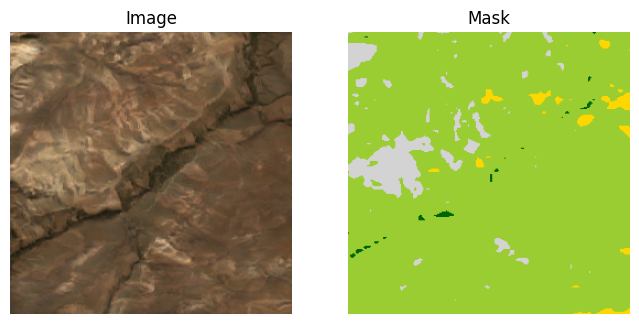

In [10]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.title("Mask")
plt.axis("off")

plt.show()

In [11]:
#The caption for the image
print("Filename:", sample_filename)
print("\nCaption:\n", sample_row["hybrid_gemma3-4b"])

Filename: 0073.png

Caption:
 The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the terrain, suggesting a significant fluvial feature within the predominantly grassy area.


**2-Class Mapping and Inspection**

In this step, the mapping between segmentation mask colors and land cover classes is defined, and the mask structure of a sample image is inspected.

The dataset provides segmentation masks in RGB format, where each pixel color corresponds to a specific land cover class. According to the project guideline, each class is associated with a predefined RGB value. Therefore,the dictionary is defined first which maps each class name to its RGB colour.

In [12]:
# Class to RGB mapping from the project guideline
class_colors = {
    "Tree":      (0, 100, 0),
    "Shrub":     (255, 182, 193),
    "Grass":     (154, 205, 50),
    "Crop":      (255, 215, 0),
    "Built-up":  (139, 69, 19),
    "Barren":    (211, 211, 211),
    "Water":     (0, 0, 255)}

print(class_colors)

{'Tree': (0, 100, 0), 'Shrub': (255, 182, 193), 'Grass': (154, 205, 50), 'Crop': (255, 215, 0), 'Built-up': (139, 69, 19), 'Barren': (211, 211, 211), 'Water': (0, 0, 255)}


The mask image is converted into a NumPy array to enable pixel wise analysis. This allows to examine the structure of the mask and extract unique RGB values from the image.

In [13]:
# Convert mask to numpy array
mask_np = np.array(mask)

print("Mask shape:", mask_np.shape)
print("First pixel example:", mask_np[0, 0])

Mask shape: (256, 256, 3)
First pixel example: [211 211 211]


Land cover classes from the spesific image can be determşne by identifying the unique colours in the corresponding mask. This step is essential for verifying that the mask encoding is consistent with the provided class color mapping.

In [14]:
# Find unique RGB colors in the mask
unique_colors = np.unique(mask_np.reshape(-1, 3), axis=0)

print("Number of unique colors in this mask:", len(unique_colors))
print("Unique colors in this mask:")
print(unique_colors)

Number of unique colors in this mask: 4
Unique colors in this mask:
[[  0 100   0]
 [154 205  50]
 [211 211 211]
 [255 215   0]]


Finally,  detected RGB values mapped to its corresponding class name. This ensures that the mask can be correctly interpreted and prepares the foundation for generating ground truth labels in the next step.

In [15]:
# Reverse mapping: RGB -> class name
color_to_class = {v: k for k, v in class_colors.items()}

# Print color-class matches found in this mask
for color in unique_colors:
    color_tuple = tuple(color)
    class_name = color_to_class.get(color_tuple, "Unknown")
    print(f"Color {color_tuple} -> {class_name}")

Color (np.uint8(0), np.uint8(100), np.uint8(0)) -> Tree
Color (np.uint8(154), np.uint8(205), np.uint8(50)) -> Grass
Color (np.uint8(211), np.uint8(211), np.uint8(211)) -> Barren
Color (np.uint8(255), np.uint8(215), np.uint8(0)) -> Crop


**3-Mask to Label**

In this step, the function which transforms a segmentation mask into a class label. The mask is represented as an RGB image, where each color corresponds to a predefined land cover class. To generate ground truth, the function first counts the number of pixels belonging to each class in the mask. Then, it computes the proportion of each class relative to the total number of pixels.

For the proof of concept, single label setting is used. In this setting the class with the highest pixel count is selected as the ground truth label. This keeps the initial pipeline simple and suitable for demonstrating feasibility. In addition to the dominant label, the function also returns class counts and ratios, which are useful for interpretation and verification.

In [16]:
def mask_to_label(mask_image, class_colors):

    # Convert mask image to NumPy array
    mask_np = np.array(mask_image)

    # Total number of pixels in the mask
    total_pixels = mask_np.shape[0] * mask_np.shape[1]

    # Dictionaries to store counts and ratios
    counts_dict = {}
    ratios_dict = {}

    # Count pixels for each class color
    for class_name, rgb_color in class_colors.items():
        # Create a boolean mask where all RGB channels match the class color
        matches = np.all(mask_np == rgb_color, axis=-1)

        # Count matching pixels
        pixel_count = np.sum(matches)

        # Store count
        counts_dict[class_name] = int(pixel_count)

        # Store ratio
        ratios_dict[class_name] = pixel_count / total_pixels

    # Find the class with the maximum pixel count
    dominant_class = max(counts_dict, key=counts_dict.get)

    return counts_dict, ratios_dict, dominant_class

After defining the function, the sample mask is tested. This helps to verify that the function is working correctly before applying it to the full dataset. The output should show the pixel counts, class ratios, and the dominant class for the selected sample.

In [17]:
counts_dict, ratios_dict, dominant_class = mask_to_label(mask, class_colors)

print("Pixel counts by class:")
for k, v in counts_dict.items():
    print(f"{k}: {v}")

print("\nClass ratios:")
for k, v in ratios_dict.items():
    print(f"{k}: {v:.4f}")

print("\nDominant class (ground truth label):", dominant_class)

Pixel counts by class:
Tree: 223
Shrub: 0
Grass: 60100
Crop: 1078
Built-up: 0
Barren: 4135
Water: 0

Class ratios:
Tree: 0.0034
Shrub: 0.0000
Grass: 0.9171
Crop: 0.0164
Built-up: 0.0000
Barren: 0.0631
Water: 0.0000

Dominant class (ground truth label): Grass


**4-Building Dataframe with Labels**

In this step, the new dataframe which stores the essential information for the PoC. For each sample, the code checks whether the corresponding image and mask files exist, loads the mask, generates the dominant class label using the previously defined function, and then stores the caption and label together.

This confirms that the pipeline is compatible with the model and suitable for PoC inference, with training and full evaluation to be conducted in later phases.

Since the dataset is large, a smaller subset during the PoC is used.

In [18]:
# small subset of the CSV for proof of concept
poc_size = 200
df_poc = df.iloc[:poc_size].copy()

print("PoC subset size:", len(df_poc))
df_poc.head()

PoC subset size: 200


,filename,split,Tree,Shrub,Grass,Crop,Built-up,Barren,Water,hybrid_gemma3-4b,hybrid_qwen3-vl-8b,text_qwen3-4b,vision_gemma3-4b,vision_qwen3-vl-8b
0,0073.png,synth,0,0,92,2,0,6,0,The image depicts a landscape dominated by ext...,The scene is dominated by grassland covering 9...,"The scene is predominantly covered by grass, i...","This image depicts a rugged, arid landscape ch...","This remote sensing image shows a rugged, arid..."
1,0077.png,synth,5,0,87,3,1,4,0,The image depicts a largely arid landscape dom...,"The scene is dominated by grasslands (87%), in...",The scene is predominantly covered by grass (8...,"The image depicts a rugged, arid landscape wit...","This remote sensing image depicts a rugged, ar..."
2,0136.png,synth,4,0,93,0,2,1,0,The image depicts a landscape dominated by ext...,The scene is dominated by grasslands covering ...,"The scene is predominantly grassland, with ove...",The image depicts a semi-arid landscape domina...,"This satellite image shows a rugged, arid moun..."
3,0172.png,synth,72,0,22,4,2,0,0,The image depicts a valley dominated by dense ...,The scene depicts a rural landscape dominated ...,"The scene is predominantly forested, with tree...",The image depicts a small town nestled within ...,This satellite image shows a small rural settl...
4,0198.png,synth,32,0,14,0,0,1,53,The image depicts a coastal area dominated by ...,The scene shows a coastal region dominated by ...,"The scene is predominantly water, covering 53%...",This image shows a coastal landscape with a na...,This satellite image shows a coastal peninsula...


In [19]:
# The caption columns that is going to be used
caption_column = "hybrid_gemma3-4b"

# List to store processed dataset rows
data_rows = []

for _, row in df_poc.iterrows():
    filename = row["filename"]

    # Build full file paths
    image_path = os.path.join(images_path, filename)
    mask_path = os.path.join(masks_path, filename)

    # Skip samples if image or mask file is missing
    if not os.path.exists(image_path) or not os.path.exists(mask_path):
        continue

    # Load the mask image
    mask_image = Image.open(mask_path).convert("RGB")

    # Generate counts, ratios, and dominant label from the mask
    counts_dict, ratios_dict, dominant_class = mask_to_label(mask_image, class_colors)

    # Store sample information
    data_rows.append({
        "filename": filename,
        "image_path": image_path,
        "mask_path": mask_path,
        "caption": row[caption_column],
        "label_name": dominant_class
    })

Samples were processed and stored in a Python list. Now, this list is converted into a pandas dataframe.

In [20]:
# convert the collected rows into a dataframe
data_df = pd.DataFrame(data_rows)

# Check how many valid samples were created
print("Number of valid samples in PoC dataframe:", len(data_df))

# Show first 5 rows
data_df.head()

Number of valid samples in PoC dataframe: 200


,filename,image_path,mask_path,caption,label_name
0,0073.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a landscape dominated by ext...,Grass
1,0077.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a largely arid landscape dom...,Grass
2,0136.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a landscape dominated by ext...,Grass
3,0172.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a valley dominated by dense ...,Tree
4,0198.png,/content/drive/MyDrive/DI725_Transformer/TermP...,/content/drive/MyDrive/DI725_Transformer/TermP...,The image depicts a coastal area dominated by ...,Water


The ground truth labels are currently stored as text values such as "Grass" or "Barren". However, the model requires numeric targets. Therefore, the fixed class order defined and each class name converted into a corresponding integer label.

In [21]:
# Define the class order used in the project
class_names = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]

# Create mapping dictionaries
class_to_id = {class_name: idx for idx, class_name in enumerate(class_names)}
id_to_class = {idx: class_name for class_name, idx in class_to_id.items()}

# Encode label names into integers
data_df["label_id"] = data_df["label_name"].map(class_to_id)

# Inspect encoded labels
data_df[["filename", "label_name", "label_id"]].head()

,filename,label_name,label_id
0,0073.png,Grass,2
1,0077.png,Grass,2
2,0136.png,Grass,2
3,0172.png,Tree,0
4,0198.png,Water,6


In [22]:
# Check the distribution of dominant classes
print(data_df["label_name"].value_counts())

label_name
Grass       101
Tree         66
Crop         26
Water         4
Barren        2
Built-up      1
Name: count, dtype: int64


In [23]:
# Inspect one processed sample
sample_processed = data_df.iloc[0]

print("Filename:", sample_processed["filename"])
print("Image path:", sample_processed["image_path"])
print("Mask path:", sample_processed["mask_path"])
print("Caption:", sample_processed["caption"])
print("Label name:", sample_processed["label_name"])
print("Label id:", sample_processed["label_id"])

Filename: 0073.png
Image path: /content/drive/MyDrive/DI725_Transformer/TermProject/images/0073.png
Mask path: /content/drive/MyDrive/DI725_Transformer/TermProject/masks/0073.png
Caption: The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the terrain, suggesting a significant fluvial feature within the predominantly grassy area.
Label name: Grass
Label id: 2


**5-Train / Validation / Test Split**

In this step, the processed PoC dataframe is divided into training, validation, and test sets.

Normally, stratified splitting should be used to preserve class distributions in the train validation and test set. But it is seen from previous outputs that there is only 1 "Built-up" image in this subset, which means it is not suitable for stratified sampling.

Since the goal of the proof of concept is to demonstrate feasibility rather than perfect class balancing, a standard random split is used at this stage.

In [24]:
print("Processed PoC dataset size:", len(data_df))

Processed PoC dataset size: 200


In [25]:
# Non-stratified split for PoC
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.4,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 120
Validation size: 40
Test size: 40


In [26]:
print("Train class distribution:\n", train_df["label_name"].value_counts(), "\n")
print("Validation class distribution:\n", val_df["label_name"].value_counts(), "\n")
print("Test class distribution:\n", test_df["label_name"].value_counts())

Train class distribution:
 label_name
Grass     65
Tree      32
Crop      19
Water      3
Barren     1
Name: count, dtype: int64 

Validation class distribution:
 label_name
Tree        18
Grass       18
Crop         2
Water        1
Built-up     1
Name: count, dtype: int64 

Test class distribution:
 label_name
Grass     18
Tree      16
Crop       5
Barren     1
Name: count, dtype: int64


**6-FLAVA Inputs Preparing**

FLAVA requires inputs to be formatted in a specific way. The processor handles this preparation step. It converts raw images and text into tensors that are compatible with the FLAVA model. The same processor used for both image only and image+text settings so that the input pipeline remains consistent.

In [27]:
from transformers import FlavaProcessor

# Load the FLAVA processor
processor = FlavaProcessor.from_pretrained("facebook/flava-full")

print("FLAVA processor loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/881 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/358 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

FLAVA processor loaded successfully.


In this step, a custom PyTorch dataset class is designed. This class reads one sample at a time from the dataframe, loads the image, takes the caption, and prepares the input using the FLAVA processor.

To keep the project aligned with design, the dataset class supports both image only mode and image + text mode.

This allows to use the same dataset structure for both experiments later.

In [28]:
class FlavaClassificationDataset(Dataset):
    def __init__(self, dataframe, processor, use_text=True):

        self.dataframe = dataframe
        self.processor = processor
        self.use_text = use_text  #use_Text=True means image + caption mode, use_text=False means image mode

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        # load image and convert to RGB to ensure consistent format
        image = Image.open(row["image_path"]).convert("RGB")

        # Get caption only if text is enabled
        text = row["caption"] if self.use_text else ""

        # Process image and text together
        encoding = self.processor(
            images=image,
            text=text,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=64
        )

        # Remove the extra batch dimension added by the processor
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}

        # Add label
        encoding["labels"] = torch.tensor(row["label_id"], dtype=torch.long)

        return encoding

In [29]:
# Image-only datasets
train_dataset_img = FlavaClassificationDataset(train_df, processor, use_text=False)
val_dataset_img = FlavaClassificationDataset(val_df, processor, use_text=False)
test_dataset_img = FlavaClassificationDataset(test_df, processor, use_text=False)

# image + text datasets
train_dataset_multimodal = FlavaClassificationDataset(train_df, processor, use_text=True)
val_dataset_multimodal = FlavaClassificationDataset(val_df, processor, use_text=True)
test_dataset_multimodal = FlavaClassificationDataset(test_df, processor, use_text=True)

print("Datasets created successfully.")

Datasets created successfully.


Before creating dataloaders or training the model, one processed sample is inspected. This helps to verify that the dataset is returning the expected FLAVA inputs and the correct label.

In [30]:
# Inspect one image only sample
sample_img = train_dataset_img[0]

print("Image-only sample keys:", sample_img.keys())
for k, v in sample_img.items():
    print(k, v.shape if hasattr(v, "shape") else v)

Image-only sample keys: dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])
pixel_values torch.Size([3, 224, 224])
input_ids torch.Size([64])
token_type_ids torch.Size([64])
attention_mask torch.Size([64])
labels torch.Size([])


The multimodal version of the dataset checked and to confirm that both image and caption are being prepared correctly.

In [31]:
# inspect one image + text sample
sample_multi = train_dataset_multimodal[0]

print("Image + text sample keys:", sample_multi.keys())
for k, v in sample_multi.items():
    print(k, v.shape if hasattr(v, "shape") else v)

Image + text sample keys: dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])
pixel_values torch.Size([3, 224, 224])
input_ids torch.Size([64])
token_type_ids torch.Size([64])
attention_mask torch.Size([64])
labels torch.Size([])


This step verifies that both image only and image+text inputs can be successfully processed using the FLAVA processor. The dataset returns correctly formatted tensors, including image features and tokenized text inputs, along with corresponding ground truth labels. This confirms that the data pipeline is compatible with the FLAVA model and suitable for subsequent training and evaluation.

The outputs for both image only and image+text samples appear structurally identical. This is expected behavior due to the design of the FLAVA model. This model is a unified multimodal transformer which processes both image and text inputs inthe same architecture. Therefore even in the image only setting, the model still needs a text related inputs like "input_ids", "attention_mask" and "token_type_ids"

In the image only case, these text inputs are typically empty or default placeholders. On the other hand,  in the image+text case, it contains meaningful tokenized captions.

**7-Dataloaders for Image Only Setting**

In this step, dataloaders are created for the image only version of the experiment.

A dataloader groups dataset samples into batches, which makes model training and evaluation more efficient.

The training dataloader uses shuffling so that samples are presented in random order during training, while validation and test dataloaders keep the original order.

In [32]:
# batch size for PoC
batch_size = 8

# Image only dataloaders
train_loader_img = DataLoader(train_dataset_img, batch_size=batch_size, shuffle=True)
val_loader_img = DataLoader(val_dataset_img, batch_size=batch_size, shuffle=False)
test_loader_img = DataLoader(test_dataset_img, batch_size=batch_size, shuffle=False)

print("Image-only dataloaders created successfully.")

Image-only dataloaders created successfully.


**8-Dataloaders for Image+Text**

This step creates dataloaders for the multimodal version of the experiment, where both images and captions are used as input. The same batching logic is applied so that the two settings remain comparabl

In [33]:
# Image + text dataloaders
train_loader_multi = DataLoader(train_dataset_multimodal, batch_size=batch_size, shuffle=True)
val_loader_multi = DataLoader(val_dataset_multimodal, batch_size=batch_size, shuffle=False)
test_loader_multi = DataLoader(test_dataset_multimodal, batch_size=batch_size, shuffle=False)

print("Image + text dataloaders created successfully.")

Image + text dataloaders created successfully.


In [34]:
# Inspect one batch from image-only dataloader
batch_img = next(iter(train_loader_img))

print("Image-only batch keys:", batch_img.keys())
for k, v in batch_img.items():
    print(k, v.shape)

Image-only batch keys: dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])
pixel_values torch.Size([8, 3, 224, 224])
input_ids torch.Size([8, 64])
token_type_ids torch.Size([8, 64])
attention_mask torch.Size([8, 64])
labels torch.Size([8])


In [35]:
# Inspect one batch from image + text dataloader
batch_multi = next(iter(train_loader_multi))

print("Image + text batch keys:", batch_multi.keys())
for k, v in batch_multi.items():
    print(k, v.shape)

Image + text batch keys: dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])
pixel_values torch.Size([8, 3, 224, 224])
input_ids torch.Size([8, 64])
token_type_ids torch.Size([8, 64])
attention_mask torch.Size([8, 64])
labels torch.Size([8])


This step verifies that both image only and image+text datasets can be successfully batched using PyTorch DataLoaders.

Like mentioned before, the image only setting uses empty text inputs. On the other hand, the image+text setting incorporates meaningful captionsç

This confirms that the data pipeline is fully compatible with the FLAVA model and ready for training.

**9-FLAVA Model**

In this step, the custom classification model built on top of FLAVA is defined.

The FLAVA backbone is used as a feature extractor, and a linear classification head is added to map the learned representation to the project’s 7 land cover classes.

The same model structure will be used for both image only and image+text. This keeps the architecture fixed and ensures that the comparison focuses on the effect of adding captions rather than changing the model design.

For the PoC, the multimodal representation is used when text is available and the image representation when text is not used.

In [36]:
class FlavaForClassification(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Load pretrained FLAVA backbone
        self.flava = FlavaModel.from_pretrained("facebook/flava-full")

        # FLAVA hidden size is 768 for the base model
        hidden_size = self.flava.config.hidden_size

        # Simple classification head
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, pixel_values, input_ids, attention_mask, token_type_ids, use_text=True):
        # Get FLAVA outputs
        outputs = self.flava(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True
        )

        # If text is used, take multimodal pooled output
        if use_text:
            pooled_output = outputs.multimodal_output.pooler_output
        else:
            # If text is not used, take image pooled output
            pooled_output = outputs.image_output.pooler_output

        # Classification logits
        logits = self.classifier(pooled_output)

        return logits

After defining the model class, it is  instantiated and moved to the selected device. This prepares the model for forward passes and later training.

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [38]:
# Number of project classes
num_classes = len(class_names)

# Create model
model = FlavaForClassification(num_classes=num_classes).to(device)

print("Model created successfully.")
print("Using device:", device)

pytorch_model.bin:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
image_codebook.blocks.group_1.group.block_2.res_path.path.conv_4.weight | UNEXPECTED |  | 
image_codebook.blocks.group_3.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_2.res_path.path.conv_2.bias   | UNEXPECTED |  | 
mmm_image_head.transform.dense.bias                                     | UNEXPECTED |  | 
mim_head.decoder.bias                                                   | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.weight | UNEXPECTED |  | 
mim_head.decoder.weight                                                 | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
mmm_image_head.decoder.bias              

model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

Model created successfully.
Using device: cuda


Since this is a single label classification problem in the PoC stage, the  CrossEntropyLoss is used. This is the standard loss for multiclass classification when each sample belongs to exactly one class.

The AdamW optimizer is used during training for model weight updates.

In [39]:
# Loss function for single label classification
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

print("Loss and optimizer are ready.")

Loss and optimizer are ready.


Before training, the model tested with one batch from the image only dataloader. It confirms that the forward pass works correctly and that the output has the expected shape.

In [40]:
# Get one image only batch
batch_img = next(iter(train_loader_img))
batch_img = {k: v.to(device) for k, v in batch_img.items()}

# Forward pass in image only mode
with torch.no_grad():
    logits_img = model(
        pixel_values=batch_img["pixel_values"],
        input_ids=batch_img["input_ids"],
        attention_mask=batch_img["attention_mask"],
        token_type_ids=batch_img["token_type_ids"],
        use_text=False
    )

print("Image-only logits shape:", logits_img.shape)

Image-only logits shape: torch.Size([8, 7])


The multimodal also tested with one batch from the image+text dataloader.

In [41]:
# Get one image + text batch
batch_multi = next(iter(train_loader_multi))
batch_multi = {k: v.to(device) for k, v in batch_multi.items()}

# Forward pass in image + text mode
with torch.no_grad():
    logits_multi = model(
        pixel_values=batch_multi["pixel_values"],
        input_ids=batch_multi["input_ids"],
        attention_mask=batch_multi["attention_mask"],
        token_type_ids=batch_multi["token_type_ids"],
        use_text=True
    )

print("Image + text logits shape:", logits_multi.shape)

Image + text logits shape: torch.Size([8, 7])


In [42]:
# Convert logits to predicted class ids
preds_img = torch.argmax(logits_img, dim=1)
preds_multi = torch.argmax(logits_multi, dim=1)

print("Image-only predicted class ids:", preds_img.cpu().numpy())
print("Image + text predicted class ids:", preds_multi.cpu().numpy())
print("True labels:", batch_img["labels"].cpu().numpy())

Image-only predicted class ids: [5 5 5 5 5 5 5 5]
Image + text predicted class ids: [5 5 5 5 5 5 5 5]
True labels: [2 2 0 0 2 2 2 2]


In this final step, the model outputs were converted into predicted class labels and compared with the corresponding ground truth labels derived from segmentation masks. The results show that both image only and image+text configurations currently produce similar predictions, which do not yet align with the true labels.

This behavior is expected at the PoC stage, as the classification head has not been trained and the model weights have not been fine tuned for the specific task. The predictions therefore reflect the initial state of the model rather than meaningful learning.

Despite this, the experiment successfully demonstrates that the complete pipeline from data loading and mask based ground truth generation to FLAVA based multimodal input processing and prediction. The model produces valid logits and class predictions that can be directly compared with ground truth labels.

It confirms the feasibility of the proposed approach. In subsequent phases, training and optimization will be applied to evaluate whether incorporating textual information improves classification performance compared to the image only setting.

**PHASE 2**

**1-Phase 2 Reproducibility, Leakage Safe Text Setup, and Benchmark Split**

Phase 1 PoC cells are kept unchanged. All Phase 2 improvements are implemented from this section onward.

In Phase 2, the goal is to obtain reliable preliminary benchmarking results for the research question.

Phase 2 uses a leakage safe text column, removes the earlier random 1000 sample subset, uses the full available dataset pool, and creates a controlled top 3 benchmark using the dominant classes which are "Grass", "Tree", and "Crop".

GitHub is used for code version control and reproducibility. W&B is configured as optional experiment tracking.

In [43]:
!pip install -q wandb

import os
import re
import time
import copy
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import FlavaProcessor, FlavaModel

import matplotlib.pyplot as plt
import wandb

In [44]:
# Reproducibility and device setup

GITHUB_REPO_URL = "https://github.com/aardaa-1/DI725-Term-Project"

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("GitHub repo:", GITHUB_REPO_URL)

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
GitHub repo: https://github.com/aardaa-1/DI725-Term-Project


The random seed fixed for reproducibility. The GitHub repository link is included to document code version control for the project. The dataset itself is not stored in GitHub, only the codebase and reproducibility files are versioned.

In [81]:

# Phase 2 configuration

MODEL_NAME = "facebook/flava-full"

PHASE2_TEXT_COLUMN = "vision_qwen3-vl-8b"  # Selected column from caption.csv

# Column name that will be created for Phase 2 textual input
PHASE2_CAPTION_COL = "phase2_caption"

# Class setup
CLASS_COLS = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]

CLASS_MODE = "top3"
TOP_CLASSES = ["Grass", "Tree", "Crop"]

# Split setup
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20

# Training setup
NUM_EPOCHS = 5
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
MAX_TEXT_LENGTH = 64

# DataLoader setup
NUM_WORKERS = 4
PIN_MEMORY = True if torch.cuda.is_available() else False
PERSISTENT_WORKERS = True if NUM_WORKERS > 0 else False

# Wandb setup
USE_WANDB = True
WANDB_PROJECT = "DI725_Term Project"
WANDB_ENTITY = "aardaatar-"

print("Phase 2 Experiment Configuration")
print("Model:", MODEL_NAME)
print("Selected Phase 2 text column:", PHASE2_TEXT_COLUMN)
print("Class mode:", CLASS_MODE)
print("Top classes:", TOP_CLASSES)
print("Epochs:", NUM_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Num workers:", NUM_WORKERS)
print("Use W&B:", USE_WANDB)

Phase 2 Experiment Configuration
Model: facebook/flava-full
Selected Phase 2 text column: vision_qwen3-vl-8b
Class mode: top3
Top classes: ['Grass', 'Tree', 'Crop']
Epochs: 5
Batch size: 8
Learning rate: 2e-05
Num workers: 4
Use W&B: True


The texts are selected from "vision_qwen3-vl-8b" column. It will be checked for leakage indicators before being used in the image+text model.

The benchmark is configured as a controlled top 3 classification task using "Grass", "Tree", and "Crop". The full 7 class setup is planned for Phase 3.

In [82]:

# Wandb configuration

if USE_WANDB:
    if wandb.run is not None:
        wandb.finish()

    wandb.login()

    wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=f"{CLASS_MODE}_{PHASE2_TEXT_COLUMN}_phase2",
        config={
            "seed": SEED,
            "github_repo": GITHUB_REPO_URL,
            "model_name": MODEL_NAME,
            "phase2_text_column": PHASE2_TEXT_COLUMN,
            "class_mode": CLASS_MODE,
            "top_classes": TOP_CLASSES,
            "num_epochs": NUM_EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "max_text_length": MAX_TEXT_LENGTH,
            "train_ratio": TRAIN_RATIO,
            "val_ratio": VAL_RATIO,
            "test_ratio": TEST_RATIO,
            "num_workers": NUM_WORKERS,
            "pin_memory": PIN_MEMORY,
            "persistent_workers": PERSISTENT_WORKERS,
        }
    )

    print("W&B tracking is enabled.")
else:
    print("W&B tracking is disabled.")

dataset/full_available_size,▁▁
dataset/num_classes,▁▁
dataset/phase2_benchmark_size,▁▁
dataset/test_size,▁▁
dataset/train_size,▁▁
dataset/val_size,▁▁
image_only/epoch,▁▅█
image_only/train_accuracy,▁▆█
image_only/train_epoch_time_sec,█▁▁
image_only/train_loss,█▃▁
+18,...


W&B tracking is enabled.


Wandb Link:https://wandb.ai/aardaatar-/DI725_Term%20Project?nw=nwuseraardaatar

W&B is initialized for experiment tracking. The run stores the main Phase 2 configuration, including the selected FLAVA checkpoint, text column, class setup, training parameters, DataLoader settings, and GitHub repository link. This makes the image only and image+text experiments easier to compare.

**2-Data Leakage Check for Text Columns**

Captions which contain explicit class percentages may leak target related information into the text input. Therefore, the caption columns are checked for percentage symbols, percentage related words, class percentage patterns, and composition related terms.

In [83]:
# Leakage check setup for caption columns

candidate_caption_columns = [
    "hybrid_gemma3-4b",
    "hybrid_qwen3-vl-8b",
    "text_qwen3-4b",
    "vision_gemma3-4b",
    "vision_qwen3-vl-8b"
]

candidate_caption_columns = [col for col in candidate_caption_columns if col in df.columns]

percentage_symbol_pattern = r"\b\d{1,3}(?:\.\d+)?\s*%"
percentage_word_pattern = r"\b\d{1,3}(?:\.\d+)?\s*(percent|percentage|per cent)\b"
class_terms_pattern = r"(?:tree|shrub|grass|crop|built[- ]?up|barren|water)"

class_percentage_pattern = (
    rf"{class_terms_pattern}.{{0,40}}\b\d{{1,3}}(?:\.\d+)?\s*%"
    rf"|"
    rf"\b\d{{1,3}}(?:\.\d+)?\s*%.{{0,40}}{class_terms_pattern}"
)

composition_words_pattern = r"\b(class composition|composition percentage|dominant class|percentage of each class)\b"

def count_pattern_matches(series, pattern):
    text_series = series.fillna("").astype(str).str.lower()
    return text_series.str.contains(pattern, regex=True, na=False).sum()

print("Candidate caption columns:")
print(candidate_caption_columns)

Candidate caption columns:
['hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']


In [84]:
#summary
leakage_summary_rows = []

for col in candidate_caption_columns:
    col_series = df[col]

    leakage_summary_rows.append({
        "caption_column": col,
        "percentage_symbol_count": count_pattern_matches(col_series, percentage_symbol_pattern),
        "percentage_word_count": count_pattern_matches(col_series, percentage_word_pattern),
        "class_percentage_pattern_count": count_pattern_matches(col_series, class_percentage_pattern),
        "composition_words_count": count_pattern_matches(col_series, composition_words_pattern)
    })

leakage_summary_df = pd.DataFrame(leakage_summary_rows)

print("Leakage indicator summary for caption columns:")
display(leakage_summary_df)

/tmp/ipykernel_876/1571942411.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()
/tmp/ipykernel_876/1571942411.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()
/tmp/ipykernel_876/1571942411.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()
/tmp/ipykernel_876/1571942411.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()
/tmp/ipykernel_876/1571942411.py:29:

Leakage indicator summary for caption columns:


/tmp/ipykernel_876/1571942411.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()


,caption_column,percentage_symbol_count,percentage_word_count,class_percentage_pattern_count,composition_words_count
0,hybrid_gemma3-4b,9586,0,9505,0
1,hybrid_qwen3-vl-8b,8399,0,8390,0
2,text_qwen3-4b,7276,0,7179,0
3,vision_gemma3-4b,1,0,0,0
4,vision_qwen3-vl-8b,0,0,0,0


In [85]:
# Detailed leakage check

selected_series = df[PHASE2_TEXT_COLUMN].fillna("").astype(str)

selected_percentage_symbol_count = count_pattern_matches(selected_series, percentage_symbol_pattern)
selected_percentage_word_count = count_pattern_matches(selected_series, percentage_word_pattern)
selected_class_percentage_count = count_pattern_matches(selected_series, class_percentage_pattern)
selected_composition_words_count = count_pattern_matches(selected_series, composition_words_pattern)

print("Selected Phase 2 text column:", PHASE2_TEXT_COLUMN)
print("Percentage symbol count:", selected_percentage_symbol_count)
print("Percentage word count:", selected_percentage_word_count)
print("Class-percentage pattern count:", selected_class_percentage_count)
print("Composition-related word count:", selected_composition_words_count)

if USE_WANDB and wandb.run is not None:
    wandb.log({
        "leakage_check/selected_percentage_symbol_count": selected_percentage_symbol_count,
        "leakage_check/selected_percentage_word_count": selected_percentage_word_count,
        "leakage_check/selected_class_percentage_pattern_count": selected_class_percentage_count,
        "leakage_check/selected_composition_words_count": selected_composition_words_count,
    })

/tmp/ipykernel_876/1571942411.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()


Selected Phase 2 text column: vision_qwen3-vl-8b
Percentage symbol count: 0
Percentage word count: 0
Class-percentage pattern count: 0
Composition-related word count: 0


/tmp/ipykernel_876/1571942411.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return text_series.str.contains(pattern, regex=True, na=False).sum()


Previously used "hybrid_gemma3-4b" caption column contains explicit percentage indicators in most samples, which would leak target related class composition information into the text input.

In contrast, the selected Phase 2 text column, "vision_qwen3-vl-8b", contains no explicit percentage symbols, percentage words, class percentage patterns, or composition related leakage indicators. Therefore, this column is used as the textual input for the image+text FLAVA experiment.

**3-Full Dataset Preparation for Phase 2**

The random 1000 sample subset used in earlier Phase 2 trials is removed. Instead, the full available dataset is processed. Image and mask paths are created, missing files are removed, and the selected leakage safe text column is copied into a dedicated Phase 2 caption column.

In [86]:
# Preparing the Phase 2 dataframe

data_df_2 = df.copy()

data_df_2["image_path"] = data_df_2["filename"].apply(lambda x: os.path.join(images_path, x))
data_df_2["mask_path"] = data_df_2["filename"].apply(lambda x: os.path.join(masks_path, x))

# Keeping only rows whose image and mask files exist
data_df_2 = data_df_2[
    data_df_2["image_path"].apply(os.path.exists) &
    data_df_2["mask_path"].apply(os.path.exists)
].reset_index(drop=True)

# Using the leakage safe Phase 2 text column
data_df_2[PHASE2_CAPTION_COL] = data_df_2[PHASE2_TEXT_COLUMN].fillna("").astype(str)

# Derive dominant class label from class composition columns
data_df_2["label_name"] = data_df_2[CLASS_COLS].idxmax(axis=1)
data_df_2["dominant_ratio"] = data_df_2[CLASS_COLS].max(axis=1)

print("Full available dataset size after file existence check:", len(data_df_2))

print("\nSample rows:")
display(data_df_2[["filename", PHASE2_CAPTION_COL, "label_name", "dominant_ratio"]].head())

Full available dataset size after file existence check: 10000

Sample rows:


,filename,phase2_caption,label_name,dominant_ratio
0,0073.png,"This remote sensing image shows a rugged, arid...",Grass,92
1,0077.png,"This remote sensing image depicts a rugged, ar...",Grass,87
2,0136.png,"This satellite image shows a rugged, arid moun...",Grass,93
3,0172.png,This satellite image shows a small rural settl...,Tree,72
4,0198.png,This satellite image shows a coastal peninsula...,Water,53


According to results, full dataframe for Phase 2 successfully prepared using all 10.000 available samples.

Each row now includes the image path, mask path, leakage safe Phase 2 caption, dominant class label, and dominant class ratio.

The sample rows show that the selected "vision_qwen3-vl-8b" captions describe the image content without explicit class percentage labels.

In [87]:
# dataset class distribution

full_class_distribution = (
    data_df_2["label_name"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)

print("Full dataset dominant class distribution:")
display(full_class_distribution)

print("\nFull dataset dominant ratio summary:")
display(data_df_2.groupby("label_name")["dominant_ratio"].describe())

Full dataset dominant class distribution:


,class,count
0,Grass,4703
1,Tree,3037
2,Crop,1803
3,Barren,193
4,Water,178
5,Built-up,59
6,Shrub,27



Full dataset dominant ratio summary:


,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Barren,193.0,71.134715,15.591547,38.0,58.00,73.0,85.00,100.0
Built-up,59.0,56.101695,14.734074,27.0,44.00,54.0,67.00,88.0
Crop,1803.0,78.222407,17.278643,32.0,64.00,81.0,94.00,100.0
Grass,4703.0,77.672124,16.177848,32.0,64.00,81.0,92.00,100.0
Shrub,27.0,46.592593,6.829006,35.0,42.00,47.0,50.50,66.0
Tree,3037.0,77.720448,16.760300,26.0,64.00,80.0,93.00,100.0
Water,178.0,63.938202,15.957982,33.0,51.25,62.5,75.75,99.0


The dataset distribution shows a class imbalance. The dominant classes are "Grass", "Tree", and "Crop", which together cover 9.543 out of 10.000 samples.

Based on this distribution, in Phase 2 controlled top 3 benchmark is used with "Grass", "Tree", and "Crop".

In [88]:
# top 3 benchmark filtering

if CLASS_MODE == "top3":
    selected_classes = TOP_CLASSES
elif CLASS_MODE == "all7":
    selected_classes = CLASS_COLS
else:
    raise ValueError("CLASS_MODE must be either 'top3' or 'all7'.")

phase2_df = data_df_2[data_df_2["label_name"].isin(selected_classes)].copy()
phase2_df = phase2_df.reset_index(drop=True)

print("Selected class mode:", CLASS_MODE)
print("Selected classes:", selected_classes)
print("Phase 2 benchmark dataset size:", len(phase2_df))

print("\nPhase 2 class distribution before split:")
display(phase2_df["label_name"].value_counts().rename_axis("class").reset_index(name="count"))

Selected class mode: top3
Selected classes: ['Grass', 'Tree', 'Crop']
Phase 2 benchmark dataset size: 9543

Phase 2 class distribution before split:


,class,count
0,Grass,4703
1,Tree,3037
2,Crop,1803


In [89]:
# Label mapping
label2id = {label: idx for idx, label in enumerate(selected_classes)}
id2label = {idx: label for label, idx in label2id.items()}

phase2_df["label_id"] = phase2_df["label_name"].map(label2id)

print("Label mapping:")
print(label2id)

print("\nSample rows with label IDs:")
display(phase2_df[["filename", "label_name", "label_id"]].head())

Label mapping:
{'Grass': 0, 'Tree': 1, 'Crop': 2}

Sample rows with label IDs:


,filename,label_name,label_id
0,0073.png,Grass,0
1,0077.png,Grass,0
2,0136.png,Grass,0
3,0172.png,Tree,1
4,0212.png,Crop,2


Selected classes are converted into numeric label IDs so that they can be used by the PyTorch classification model.

In [90]:
# Stratified train / validation / test split

train_df, temp_df = train_test_split(
    phase2_df,
    test_size=(1 - TRAIN_RATIO),
    stratify=phase2_df["label_id"],
    random_state=SEED
)

relative_test_size = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df["label_id"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Split sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Split sizes:
Train: 5725
Validation: 1909
Test: 1909


Dataset is split into training, validation, and test sets using a 60/20/20 ratio.

Stratified splitting was applied so that the class distribution is preserved across all three sets.

The validation set will be used for checkpoint selection, while the test set will be used only for the final comparison between the image only and image+text models.

In [91]:
# Class distribution after splitting

print("Train class distribution:")
display(train_df["label_name"].value_counts().rename_axis("class").reset_index(name="count"))

print("\nValidation class distribution:")
display(val_df["label_name"].value_counts().rename_axis("class").reset_index(name="count"))

print("\nTest class distribution:")
display(test_df["label_name"].value_counts().rename_axis("class").reset_index(name="count"))

if USE_WANDB and wandb.run is not None:
    wandb.log({
        "dataset/full_available_size": len(data_df_2),
        "dataset/phase2_benchmark_size": len(phase2_df),
        "dataset/train_size": len(train_df),
        "dataset/val_size": len(val_df),
        "dataset/test_size": len(test_df),
        "dataset/num_classes": len(label2id),
    })

Train class distribution:


,class,count
0,Grass,2821
1,Tree,1822
2,Crop,1082



Validation class distribution:


,class,count
0,Grass,941
1,Tree,607
2,Crop,361



Test class distribution:


,class,count
0,Grass,941
1,Tree,608
2,Crop,360


The stratified split preserves the class distribution across training, validation, and test sets.

**11-Rebuilding The Datasets and DataLoader for Phase 2**

In this step, the Phase 2 training, validation, and test splits are converted into PyTorch Dataset and DataLoader objects.

Two input settings are prepared:

1. Image Only: This is the baseline model input.
2. Image + Text: This is the multimodal model input.

Both settings use the same train, validation, and test splits. This keeps the comparison fair.

In [92]:
# Loading FLAVA processor

phase2_processor = FlavaProcessor.from_pretrained(MODEL_NAME)

print("Phase 2 processor loaded from:", MODEL_NAME)

Phase 2 processor loaded from: facebook/flava-full


In [93]:
# Dataset class

class Phase2RemoteSensingDataset(Dataset):
    def __init__(self, dataframe, processor, use_text=False):
        self.df = dataframe.reset_index(drop=True)
        self.processor = processor
        self.use_text = use_text

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label_id"])

        if self.use_text:
            text = str(row[PHASE2_CAPTION_COL])

            encoding = self.processor(
                images=image,
                text=text,
                return_tensors="pt",
                padding="max_length",
                truncation=True,
                max_length=MAX_TEXT_LENGTH
            )
        else:
            encoding = self.processor(
                images=image,
                return_tensors="pt"
            )

        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        encoding["labels"] = torch.tensor(label, dtype=torch.long)

        return encoding

print("Phase 2 Dataset class is ready.")

Phase 2 Dataset class is ready.


The custom Dataset class prepares each sample for FLAVA. For the "Image Only" setting, only the image is processed.

For the "Image + Text" setting, the image and caption are processed together.

The target label is taken from the numeric "label_id" column.

In [94]:
# Creating Phase 2 Dataset objects

# Image Only Datasets
train_dataset_img = Phase2RemoteSensingDataset(train_df, phase2_processor, use_text=False)
val_dataset_img = Phase2RemoteSensingDataset(val_df, phase2_processor, use_text=False)
test_dataset_img = Phase2RemoteSensingDataset(test_df, phase2_processor, use_text=False)

# Image + Text Datasets
train_dataset_mm = Phase2RemoteSensingDataset(train_df, phase2_processor, use_text=True)
val_dataset_mm = Phase2RemoteSensingDataset(val_df, phase2_processor, use_text=True)
test_dataset_mm = Phase2RemoteSensingDataset(test_df, phase2_processor, use_text=True)

print("Image Only Dataset Sizes:")
print("Train:", len(train_dataset_img), "Validation:", len(val_dataset_img), "Test:", len(test_dataset_img))

print("\nImage + Text Dataset Sizes:")
print("Train:", len(train_dataset_mm), "Validation:", len(val_dataset_mm), "Test:", len(test_dataset_mm))

Image Only Dataset Sizes:
Train: 5725 Validation: 1909 Test: 1909

Image + Text Dataset Sizes:
Train: 5725 Validation: 1909 Test: 1909


The output confirms a fair benchmark, which shows that both model is going to used same dataset.

In [95]:
# Dataset sanity check

sample_img = train_dataset_img[0]
sample_mm = train_dataset_mm[0]

print("Image Only sample keys:")
print(sample_img.keys())

print("\nImage + Text sample keys:")
print(sample_mm.keys())

print("\nImage Only pixel_values shape:", sample_img["pixel_values"].shape)
print("Image Only label:", sample_img["labels"])

print("\nImage + Text pixel_values shape:", sample_mm["pixel_values"].shape)
print("Image + Text input_ids shape:", sample_mm["input_ids"].shape)
print("Image + Text attention_mask shape:", sample_mm["attention_mask"].shape)
print("Image + Text label:", sample_mm["labels"])

Image Only sample keys:
dict_keys(['pixel_values', 'labels'])

Image + Text sample keys:
dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

Image Only pixel_values shape: torch.Size([3, 224, 224])
Image Only label: tensor(2)

Image + Text pixel_values shape: torch.Size([3, 224, 224])
Image + Text input_ids shape: torch.Size([64])
Image + Text attention_mask shape: torch.Size([64])
Image + Text label: tensor(2)


The sanity check confirms that the Dataset objects return the expected inputs for both settings.

*   The "Image Only" sample contains image tensors and a label
*   the "Image + Text" sample additionally contains text-related tensors such as "input_ids", "token_type_ids", and "attention_mask".

In [96]:
# Creating DataLoaders

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "pin_memory": PIN_MEMORY,
    "num_workers": NUM_WORKERS
}

if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = PERSISTENT_WORKERS

train_loader_img = DataLoader(train_dataset_img, shuffle=True, **loader_kwargs)
val_loader_img = DataLoader(val_dataset_img, shuffle=False, **loader_kwargs)
test_loader_img = DataLoader(test_dataset_img, shuffle=False, **loader_kwargs)

train_loader_mm = DataLoader(train_dataset_mm, shuffle=True, **loader_kwargs)
val_loader_mm = DataLoader(val_dataset_mm, shuffle=False, **loader_kwargs)
test_loader_mm = DataLoader(test_dataset_mm, shuffle=False, **loader_kwargs)

print("Number of Image Only train batches:", len(train_loader_img))
print("Number of Image + Text train batches:", len(train_loader_mm))

print("\nDataLoader settings:")
print("Batch size:", BATCH_SIZE)
print("Num workers:", NUM_WORKERS)
print("Pin memory:", PIN_MEMORY)
print("Persistent workers:", PERSISTENT_WORKERS)

Number of Image Only train batches: 716
Number of Image + Text train batches: 716

DataLoader settings:
Batch size: 8
Num workers: 4
Pin memory: True
Persistent workers: True


In [97]:
# DataLoader batch sanity check

batch_img = next(iter(train_loader_img))
batch_mm = next(iter(train_loader_mm))

print("Image Only batch keys:")
print(batch_img.keys())

print("\nImage + Text batch keys:")
print(batch_mm.keys())

print("\nImage Only batch pixel_values shape:", batch_img["pixel_values"].shape)
print("Image Only batch labels shape:", batch_img["labels"].shape)

print("\nImage + Text batch pixel_values shape:", batch_mm["pixel_values"].shape)
print("Image + Text batch input_ids shape:", batch_mm["input_ids"].shape)
print("Image + Text batch attention_mask shape:", batch_mm["attention_mask"].shape)
print("Image + Text batch labels shape:", batch_mm["labels"].shape)

Image Only batch keys:
dict_keys(['pixel_values', 'labels'])

Image + Text batch keys:
dict_keys(['pixel_values', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

Image Only batch pixel_values shape: torch.Size([8, 3, 224, 224])
Image Only batch labels shape: torch.Size([8])

Image + Text batch pixel_values shape: torch.Size([8, 3, 224, 224])
Image + Text batch input_ids shape: torch.Size([8, 64])
Image + Text batch attention_mask shape: torch.Size([8, 64])
Image + Text batch labels shape: torch.Size([8])


Images are processed as 224x224 RGB tensors and text inputs are padded or truncated to a maximum length of 64 tokens.

These DataLoaders are now ready for FLAVA model training and evaluation.

**12- Model for Training**

In this step, the trainable models for Phase 2 are defined. The goal is to compare two settings under the same classification task:

1. Image only model, which serves as the baseline.
2. Image + Text model, which serves as the multimodal version.

Both models are built on top of the same FLAVA backbone. Unlike the Phase 1 PoC, where the model was mainly used for a forward pass feasibility check, Phase 2 adds a classification head and prepares the models for supervised training on the three class benchmark dataset: "Grass", "Tree", and "Crop".

To keep the comparison fair, both models use the same FLAVA checkpoint and the same classification setup. The main difference between the two models is whether the text is included during training and evaluation.

In [98]:
# FLAVA classifier models

import torch
import torch.nn as nn
from transformers import FlavaModel

# Number of classes after filtering
num_labels = len(label2id)
print("Number of labels:", num_labels)
print("Label mapping:", label2id)


class FlavaClassifier(nn.Module):
    def __init__(self, num_labels, model_name=MODEL_NAME):
        super().__init__()
        self.flava = FlavaModel.from_pretrained(model_name)
        hidden_size = self.flava.config.hidden_size           # since the hidden size needed for classification layer and the FLAVA outputs hidden representations
        self.dropout = nn.Dropout(0.1)   #  dropout is used as a regularization layer. It is going to help to reduce overfitting
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(
        self,
        pixel_values,
        input_ids=None,
        attention_mask=None,
        token_type_ids=None,
        labels=None
    ):
        outputs = self.flava(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True
        )

        # Use image + text if there is an text, otherwise use only input
        if input_ids is not None and attention_mask is not None:
            pooled = outputs.multimodal_output.pooler_output
        else:
            pooled = outputs.image_output.pooler_output

        logits = self.classifier(self.dropout(pooled))

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return {"loss": loss, "logits": logits}


print("Using device:", device)

# Creating models
model_img = FlavaClassifier(num_labels=num_labels, model_name=MODEL_NAME).to(device)
model_mm = FlavaClassifier(num_labels=num_labels, model_name=MODEL_NAME).to(device)

#Check if models are ready or not
print("\nImage Only model ready.")
print("Image+Text model ready.")

Number of labels: 3
Label mapping: {'Grass': 0, 'Tree': 1, 'Crop': 2}
Using device: cuda


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
image_codebook.blocks.group_1.group.block_2.res_path.path.conv_4.weight | UNEXPECTED |  | 
image_codebook.blocks.group_3.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_2.res_path.path.conv_2.bias   | UNEXPECTED |  | 
mmm_image_head.transform.dense.bias                                     | UNEXPECTED |  | 
mim_head.decoder.bias                                                   | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.weight | UNEXPECTED |  | 
mim_head.decoder.weight                                                 | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
mmm_image_head.decoder.bias              

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
image_codebook.blocks.group_1.group.block_2.res_path.path.conv_4.weight | UNEXPECTED |  | 
image_codebook.blocks.group_3.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_2.res_path.path.conv_2.bias   | UNEXPECTED |  | 
mmm_image_head.transform.dense.bias                                     | UNEXPECTED |  | 
mim_head.decoder.bias                                                   | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.weight | UNEXPECTED |  | 
mim_head.decoder.weight                                                 | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
mmm_image_head.decoder.bias              


Image Only model ready.
Image+Text model ready.


Before starting training, a forward pass sanity check is performed for both Phase 2 models. This step verifies that the "Image Only" and "Image + Text" models can process one mini batch successfully and produce a valid loss value and logits.

In [99]:
# Model forward sanity check

model_img.eval()
model_mm.eval()

with torch.no_grad():
    batch_img_device = {k: v.to(device) for k, v in batch_img.items()}
    batch_mm_device = {k: v.to(device) for k, v in batch_mm.items()}

    output_img = model_img(
        pixel_values=batch_img_device["pixel_values"],
        labels=batch_img_device["labels"]
    )

    output_mm = model_mm(
        pixel_values=batch_mm_device["pixel_values"],
        input_ids=batch_mm_device["input_ids"],
        attention_mask=batch_mm_device["attention_mask"],
        token_type_ids=batch_mm_device.get("token_type_ids", None),
        labels=batch_mm_device["labels"]
    )

print("Image Only loss:", output_img["loss"].item())
print("Image Only logits shape:", output_img["logits"].shape)

print("\nImage + Text loss:", output_mm["loss"].item())
print("Image + Text logits shape:", output_mm["logits"].shape)

Image Only loss: 1.1103070974349976
Image Only logits shape: torch.Size([8, 3])

Image + Text loss: 1.091761827468872
Image + Text logits shape: torch.Size([8, 3])


Results show that "Image Only" and "Image + Text" models produced valid loss values and logits with the expected shape "[8, 3]".

Since the models are not trained yet, the initial loss values are close to the expected random baseline for a three class classification problem. This confirms that the model architecture, batch format, and label setup are compatible before starting supervised training.

**13-Training and Validation**

In this step, each model is going to be trained for one epoch at a time.

Training loss, validation loss and validation accuracy are going to be computed.

The same loop is going to be used for both image only and image+text model.

In [100]:
# Training helper functions

def sync_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def move_batch_to_device(batch, device):
    return {k: v.to(device) for k, v in batch.items()}


print("Training helper functions are ready.")

Training helper functions are ready.


In [101]:
# Single epoch training function

from tqdm import tqdm

# The function which trains the model for 1 epoch
def train_one_epoch(model, dataloader, optimizer, device):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    sync_cuda()
    start_time = time.time()

    progress_bar = tqdm(dataloader, desc="Training", leave=False)  # "tqdm" helps to monitor training without changing model behaviour

    for batch in progress_bar:
        batch = move_batch_to_device(batch, device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch.get("input_ids", None),
            attention_mask=batch.get("attention_mask", None),
            token_type_ids=batch.get("token_type_ids", None),
            labels=batch["labels"]
        )

        loss = outputs["loss"]
        logits = outputs["logits"]

        # Backward pass to compute gradients
        loss.backward()

        # optimizer.step() updates the model parameters by using gradients
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

        #compute predictions for training metrics
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(batch["labels"].detach().cpu().numpy())

    sync_cuda()
    epoch_time_sec = time.time() - start_time

    # Average training loss for the epoch
    avg_loss = total_loss / len(dataloader)

    # Training accuracy
    train_accuracy = accuracy_score(all_labels, all_preds)

    # Macro F1 calculated since the dataset is imbalanced
    train_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return {
        "loss": avg_loss,
        "accuracy": train_accuracy,
        "macro_f1": train_macro_f1,
        "epoch_time_sec": epoch_time_sec
    }


print("Single epoch training function is ready.")

Single epoch training function is ready.


In [102]:
# Evaluation function

def evaluate_model(model, dataloader, device, id2label):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    sync_cuda()
    start_time = time.time()

    with torch.no_grad():       # torch.no_grad() saves memory and speeds up evaluation
        progress_bar = tqdm(dataloader, desc="Evaluating", leave=False)

        for batch in progress_bar:
            batch = move_batch_to_device(batch, device)

            outputs = model(
                pixel_values=batch["pixel_values"],
                input_ids=batch.get("input_ids", None),
                attention_mask=batch.get("attention_mask", None),
                token_type_ids=batch.get("token_type_ids", None),
                labels=batch["labels"]
            )

            loss = outputs["loss"]
            logits = outputs["logits"]

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1) # "torch.argmax" helps to select class with highest score

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(batch["labels"].detach().cpu().numpy())

    sync_cuda()
    inference_time_sec = time.time() - start_time

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    labels_order = sorted(id2label.keys())
    target_names = [id2label[i] for i in labels_order]

    class_report = classification_report(
        all_labels,
        all_preds,
        labels=labels_order,
        target_names=target_names,
        digits=4,
        zero_division=0,
        output_dict=True
    )

    samples_per_second = len(dataloader.dataset) / inference_time_sec
    ms_per_sample = (inference_time_sec / len(dataloader.dataset)) * 1000

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "classification_report": class_report,
        "inference_time_sec": inference_time_sec,
        "samples_per_second": samples_per_second,
        "ms_per_sample": ms_per_sample,
        "labels": all_labels,
        "preds": all_preds
    }


print("Evaluation function is ready.")

Evaluation function is ready.


In [103]:
# Full model training function

def train_model(model, train_loader, val_loader, optimizer, model_name):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_macro_f1": [],
        "train_epoch_time_sec": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": [],
        "val_weighted_f1": []
    }

    best_val_macro_f1 = -1
    best_epoch = -1
    best_model_state = None

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS} - {model_name}")

        train_metrics = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            device=device
        )

        val_metrics = evaluate_model(
            model=model,
            dataloader=val_loader,
            device=device,
            id2label=id2label
        )

        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["train_epoch_time_sec"].append(train_metrics["epoch_time_sec"])

        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["val_weighted_f1"].append(val_metrics["weighted_f1"])

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())

        print(f"Train Loss: {train_metrics['loss']:.4f}")
        print(f"Train Accuracy: {train_metrics['accuracy']:.4f}")
        print(f"Train Macro F1: {train_metrics['macro_f1']:.4f}")
        print(f"Train Epoch Time: {train_metrics['epoch_time_sec']:.2f} sec")

        print(f"Val Loss: {val_metrics['loss']:.4f}")
        print(f"Val Accuracy: {val_metrics['accuracy']:.4f}")
        print(f"Val Macro F1: {val_metrics['macro_f1']:.4f}")
        print(f"Val Weighted F1: {val_metrics['weighted_f1']:.4f}")

        print("\nValidation Class-Level Metrics:")
        for class_name in [id2label[i] for i in sorted(id2label.keys())]:
            print(
                f"{class_name}: "
                f"Precision={val_metrics['classification_report'][class_name]['precision']:.4f}, "
                f"Recall={val_metrics['classification_report'][class_name]['recall']:.4f}, "
                f"F1={val_metrics['classification_report'][class_name]['f1-score']:.4f}"
            )

        if USE_WANDB and wandb.run is not None:
            wandb.log({
                f"{model_name}/epoch": epoch + 1,
                f"{model_name}/train_loss": train_metrics["loss"],
                f"{model_name}/train_accuracy": train_metrics["accuracy"],
                f"{model_name}/train_macro_f1": train_metrics["macro_f1"],
                f"{model_name}/train_epoch_time_sec": train_metrics["epoch_time_sec"],
                f"{model_name}/val_loss": val_metrics["loss"],
                f"{model_name}/val_accuracy": val_metrics["accuracy"],
                f"{model_name}/val_macro_f1": val_metrics["macro_f1"],
                f"{model_name}/val_weighted_f1": val_metrics["weighted_f1"],
            })

    history["best_epoch"] = best_epoch
    history["best_val_macro_f1"] = best_val_macro_f1
    history["best_model_state"] = best_model_state

    print(f"\nBest checkpoint for {model_name}")
    print("Best Epoch:", best_epoch)
    print("Best Validation Macro F1:", round(best_val_macro_f1, 4))

    return history


print("Full model training function is ready.")

Full model training function is ready.


In [104]:
# Optimizers for Phase 2 models

optimizer_img = torch.optim.AdamW(
    model_img.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

optimizer_mm = torch.optim.AdamW(
    model_mm.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Optimizers are ready.")
print("Image Only optimizer learning rate:", LEARNING_RATE)
print("Image + Text optimizer learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

Optimizers are ready.
Image Only optimizer learning rate: 2e-05
Image + Text optimizer learning rate: 2e-05
Weight decay: 0.01


The optimizers were created successfully for both Phase 2 models. Both the "Image Only" baseline and the "Image + Text" model use the same AdamW optimizer settings. This keeps the comparison fair.

**13.1-Training and Evaluating Image Only**

In [105]:
# Training and validating the Image Only baseline

img_history = train_model(
    model=model_img,
    train_loader=train_loader_img,
    val_loader=val_loader_img,
    optimizer=optimizer_img,
    model_name="image_only"
)

train_losses_img = img_history["train_loss"]
train_accuracies_img = img_history["train_accuracy"]
train_macro_f1s_img = img_history["train_macro_f1"]

val_losses_img = img_history["val_loss"]
val_accuracies_img = img_history["val_accuracy"]
val_macro_f1s_img = img_history["val_macro_f1"]

best_epoch_img = img_history["best_epoch"]
best_val_macro_f1_img = img_history["best_val_macro_f1"]
best_model_state_img = img_history["best_model_state"]


Epoch 1/5 - image_only


Train Loss: 0.4281
Train Accuracy: 0.8716
Train Macro F1: 0.8586
Train Epoch Time: 51.66 sec
Val Loss: 0.2211
Val Accuracy: 0.9209
Val Macro F1: 0.9147
Val Weighted F1: 0.9212

Validation Class-Level Metrics:
Grass: Precision=0.9164, Recall=0.9320, F1=0.9241
Tree: Precision=0.9655, Recall=0.9209, F1=0.9427
Crop: Precision=0.8633, Recall=0.8920, F1=0.8774

Epoch 2/5 - image_only


Train Loss: 0.2023
Train Accuracy: 0.9228
Train Macro F1: 0.9160
Train Epoch Time: 51.30 sec
Val Loss: 0.1942
Val Accuracy: 0.9288
Val Macro F1: 0.9220
Val Weighted F1: 0.9289

Validation Class-Level Metrics:
Grass: Precision=0.9196, Recall=0.9479, F1=0.9335
Tree: Precision=0.9740, Recall=0.9242, F1=0.9484
Crop: Precision=0.8815, Recall=0.8864, F1=0.8840

Epoch 3/5 - image_only


Train Loss: 0.1214
Train Accuracy: 0.9556
Train Macro F1: 0.9524
Train Epoch Time: 51.39 sec
Val Loss: 0.2432
Val Accuracy: 0.9078
Val Macro F1: 0.9021
Val Weighted F1: 0.9072

Validation Class-Level Metrics:
Grass: Precision=0.9313, Recall=0.8927, F1=0.9116
Tree: Precision=0.8617, Recall=0.9852, F1=0.9193
Crop: Precision=0.9425, Recall=0.8172, F1=0.8754

Epoch 4/5 - image_only


Train Loss: 0.0753
Train Accuracy: 0.9722
Train Macro F1: 0.9701
Train Epoch Time: 51.40 sec
Val Loss: 0.2531
Val Accuracy: 0.9162
Val Macro F1: 0.9041
Val Weighted F1: 0.9150

Validation Class-Level Metrics:
Grass: Precision=0.8829, Recall=0.9617, F1=0.9207
Tree: Precision=0.9659, Recall=0.9341, F1=0.9497
Crop: Precision=0.9327, Recall=0.7673, F1=0.8419

Epoch 5/5 - image_only


Train Loss: 0.0437
Train Accuracy: 0.9843
Train Macro F1: 0.9834
Train Epoch Time: 51.47 sec
Val Loss: 0.3680
Val Accuracy: 0.9031
Val Macro F1: 0.8863
Val Weighted F1: 0.9006

Validation Class-Level Metrics:
Grass: Precision=0.8637, Recall=0.9628, F1=0.9106
Tree: Precision=0.9496, Recall=0.9308, F1=0.9401
Crop: Precision=0.9547, Recall=0.7008, F1=0.8083

Best checkpoint for image_only
Best Epoch: 2
Best Validation Macro F1: 0.922


The "Image Only" baseline was trained successfully for five epochs. The best validation macro F1 score was obtained at epoch 2. After this point, training performance continued to improve, but validation performance decreased, indicating the beginning of overfitting.

Therefore, the epoch 2 checkpoint was selected for the final test evaluation.

**13.2-Training and Evaluating Image +Text**

In [108]:
# Training and validating the Image+Text

class FlavaFusionClassifier(nn.Module):
    def __init__(self, num_labels, model_name=MODEL_NAME):
        super().__init__()

        self.flava = FlavaModel.from_pretrained(model_name)
        hidden_size = self.flava.config.hidden_size

        # The fusion classifier uses image, text, and multimodal representations together.
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_size * 3, num_labels)

    def forward(
        self,
        pixel_values,
        input_ids=None,
        attention_mask=None,
        token_type_ids=None,
        labels=None
    ):
        outputs = self.flava(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True
        )

        image_pooled = outputs.image_output.pooler_output
        text_pooled = outputs.text_output.pooler_output
        multimodal_pooled = outputs.multimodal_output.pooler_output

        fused_features = torch.cat(
            [image_pooled, text_pooled, multimodal_pooled],
            dim=1
        )

        logits = self.classifier(self.dropout(fused_features))

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return {
            "loss": loss,
            "logits": logits
        }


model_mm = FlavaFusionClassifier(num_labels=num_labels, model_name=MODEL_NAME).to(device)

optimizer_mm = torch.optim.AdamW(
    model_mm.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Improved Image + Text fusion model is ready.")
print("Image Only baseline is kept unchanged.")

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

FlavaModel LOAD REPORT from: facebook/flava-full
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
image_codebook.blocks.group_1.group.block_2.res_path.path.conv_4.weight | UNEXPECTED |  | 
image_codebook.blocks.group_3.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_2.res_path.path.conv_2.bias   | UNEXPECTED |  | 
mmm_image_head.transform.dense.bias                                     | UNEXPECTED |  | 
mim_head.decoder.bias                                                   | UNEXPECTED |  | 
image_codebook.blocks.group_2.group.block_1.res_path.path.conv_2.weight | UNEXPECTED |  | 
mim_head.decoder.weight                                                 | UNEXPECTED |  | 
image_codebook.blocks.group_1.group.block_1.res_path.path.conv_1.bias   | UNEXPECTED |  | 
mmm_image_head.decoder.bias              

Improved Image + Text fusion model is ready.
Image Only baseline is kept unchanged.


In [109]:
mm_history = train_model(
    model=model_mm,
    train_loader=train_loader_mm,
    val_loader=val_loader_mm,
    optimizer=optimizer_mm,
    model_name="image_text"
)

train_losses_mm = mm_history["train_loss"]
train_accuracies_mm = mm_history["train_accuracy"]
train_macro_f1s_mm = mm_history["train_macro_f1"]

val_losses_mm = mm_history["val_loss"]
val_accuracies_mm = mm_history["val_accuracy"]
val_macro_f1s_mm = mm_history["val_macro_f1"]

best_epoch_mm = mm_history["best_epoch"]
best_val_macro_f1_mm = mm_history["best_val_macro_f1"]
best_model_state_mm = mm_history["best_model_state"]


Epoch 1/5 - image_text


Train Loss: 0.3718
Train Accuracy: 0.8721
Train Macro F1: 0.8620
Train Epoch Time: 104.90 sec
Val Loss: 0.2355
Val Accuracy: 0.9104
Val Macro F1: 0.9042
Val Weighted F1: 0.9110

Validation Class-Level Metrics:
Grass: Precision=0.9443, Recall=0.8831, F1=0.9127
Tree: Precision=0.9288, Recall=0.9456, F1=0.9371
Crop: Precision=0.8102, Recall=0.9224, F1=0.8627

Epoch 2/5 - image_text


Train Loss: 0.2001
Train Accuracy: 0.9237
Train Macro F1: 0.9178
Train Epoch Time: 104.49 sec
Val Loss: 0.2384
Val Accuracy: 0.9036
Val Macro F1: 0.8946
Val Weighted F1: 0.9037

Validation Class-Level Metrics:
Grass: Precision=0.9321, Recall=0.8895, F1=0.9103
Tree: Precision=0.9072, Recall=0.9506, F1=0.9284
Crop: Precision=0.8293, Recall=0.8615, F1=0.8451

Epoch 3/5 - image_text


Train Loss: 0.1387
Train Accuracy: 0.9467
Train Macro F1: 0.9425
Train Epoch Time: 104.81 sec
Val Loss: 0.1971
Val Accuracy: 0.9172
Val Macro F1: 0.9109
Val Weighted F1: 0.9174

Validation Class-Level Metrics:
Grass: Precision=0.9361, Recall=0.9033, F1=0.9194
Tree: Precision=0.9321, Recall=0.9506, F1=0.9413
Crop: Precision=0.8482, Recall=0.8975, F1=0.8721

Epoch 4/5 - image_text


Train Loss: 0.0866
Train Accuracy: 0.9682
Train Macro F1: 0.9651
Train Epoch Time: 104.46 sec
Val Loss: 0.2141
Val Accuracy: 0.9256
Val Macro F1: 0.9179
Val Weighted F1: 0.9253

Validation Class-Level Metrics:
Grass: Precision=0.9004, Recall=0.9607, F1=0.9296
Tree: Precision=0.9706, Recall=0.9259, F1=0.9477
Crop: Precision=0.9233, Recall=0.8338, F1=0.8763

Epoch 5/5 - image_text


Train Loss: 0.0488
Train Accuracy: 0.9839
Train Macro F1: 0.9828
Train Epoch Time: 104.43 sec
Val Loss: 0.2303
Val Accuracy: 0.9219
Val Macro F1: 0.9153
Val Weighted F1: 0.9221

Validation Class-Level Metrics:
Grass: Precision=0.9218, Recall=0.9267, F1=0.9242
Tree: Precision=0.9548, Recall=0.9390, F1=0.9468
Crop: Precision=0.8689, Recall=0.8809, F1=0.8748

Best checkpoint for image_text
Best Epoch: 4
Best Validation Macro F1: 0.9179


The "Image + Text" model was trained for five epochs. This model combines image, text, and multimodal FLAVA representations before classification. It provides a stronger multimodal design than using only the multimodal pooled output.

The best validation checkpoint for the fusion based "Image + Text" model was obtained at epoch 4 with a validation macro F1 score of 0.9179. Although this is close to the "Image Only" baseline, it does not clearly outperform it on the validation set. Therefore, the final comparison should be based on the test set performance and inference speed of the best validation checkpoints.

**14-Test Evaluation for Image Only and Image+Text Models**

In this step, the best saved checkpoints are reloaded for test evaluation.

In [110]:
# Test evaluation

# loading best validation checkpoints
model_img.load_state_dict(best_model_state_img)
model_mm.load_state_dict(best_model_state_mm)

# evaluating "Image Only" model on test set
test_result_img = evaluate_model(
    model=model_img,
    dataloader=test_loader_img,
    device=device,
    id2label=id2label
)

# evaluating "Image + Text" model on test set
test_result_mm = evaluate_model(
    model=model_mm,
    dataloader=test_loader_mm,
    device=device,
    id2label=id2label
)

print("Best Image Only Test Results")
print(f"Test Loss: {test_result_img['loss']:.4f}")
print(f"Test Accuracy: {test_result_img['accuracy']:.4f}")
print(f"Test Macro Precision: {test_result_img['macro_precision']:.4f}")
print(f"Test Macro Recall: {test_result_img['macro_recall']:.4f}")
print(f"Test Macro F1: {test_result_img['macro_f1']:.4f}")
print(f"Test Weighted F1: {test_result_img['weighted_f1']:.4f}")
print(f"Inference Time: {test_result_img['inference_time_sec']:.2f} sec")
print(f"Samples/sec: {test_result_img['samples_per_second']:.2f}")
print(f"ms/sample: {test_result_img['ms_per_sample']:.2f}")

print("\nImage Only Class-Level Metrics:")
for class_name in [id2label[i] for i in sorted(id2label.keys())]:
    print(
        f"{class_name}: "
        f"Precision={test_result_img['classification_report'][class_name]['precision']:.4f}, "
        f"Recall={test_result_img['classification_report'][class_name]['recall']:.4f}, "
        f"F1={test_result_img['classification_report'][class_name]['f1-score']:.4f}"
    )

print("\n" + "=" * 70 + "\n")

print("Best Image + Text Test Results")
print(f"Test Loss: {test_result_mm['loss']:.4f}")
print(f"Test Accuracy: {test_result_mm['accuracy']:.4f}")
print(f"Test Macro Precision: {test_result_mm['macro_precision']:.4f}")
print(f"Test Macro Recall: {test_result_mm['macro_recall']:.4f}")
print(f"Test Macro F1: {test_result_mm['macro_f1']:.4f}")
print(f"Test Weighted F1: {test_result_mm['weighted_f1']:.4f}")
print(f"Inference Time: {test_result_mm['inference_time_sec']:.2f} sec")
print(f"Samples/sec: {test_result_mm['samples_per_second']:.2f}")
print(f"ms/sample: {test_result_mm['ms_per_sample']:.2f}")

print("\nImage + Text Class-Level Metrics:")
for class_name in [id2label[i] for i in sorted(id2label.keys())]:
    print(
        f"{class_name}: "
        f"Precision={test_result_mm['classification_report'][class_name]['precision']:.4f}, "
        f"Recall={test_result_mm['classification_report'][class_name]['recall']:.4f}, "
        f"F1={test_result_mm['classification_report'][class_name]['f1-score']:.4f}"
    )

if USE_WANDB and wandb.run is not None:
    wandb.log({
        "test/image_only_accuracy": test_result_img["accuracy"],
        "test/image_only_macro_f1": test_result_img["macro_f1"],
        "test/image_only_weighted_f1": test_result_img["weighted_f1"],
        "test/image_only_inference_time_sec": test_result_img["inference_time_sec"],
        "test/image_only_samples_per_second": test_result_img["samples_per_second"],
        "test/image_only_ms_per_sample": test_result_img["ms_per_sample"],

        "test/image_text_accuracy": test_result_mm["accuracy"],
        "test/image_text_macro_f1": test_result_mm["macro_f1"],
        "test/image_text_weighted_f1": test_result_mm["weighted_f1"],
        "test/image_text_inference_time_sec": test_result_mm["inference_time_sec"],
        "test/image_text_samples_per_second": test_result_mm["samples_per_second"],
        "test/image_text_ms_per_sample": test_result_mm["ms_per_sample"],
    })

Best Image Only Test Results
Test Loss: 0.2075
Test Accuracy: 0.9146
Test Macro Precision: 0.9195
Test Macro Recall: 0.8994
Test Macro F1: 0.9084
Test Weighted F1: 0.9146
Inference Time: 218.65 sec
Samples/sec: 8.73
ms/sample: 114.54

Image Only Class-Level Metrics:
Grass: Precision=0.8887, Recall=0.9501, F1=0.9183
Tree: Precision=0.9698, Recall=0.8980, F1=0.9325
Crop: Precision=0.9000, Recall=0.8500, F1=0.8743


Best Image + Text Test Results
Test Loss: 0.2703
Test Accuracy: 0.9157
Test Macro Precision: 0.9231
Test Macro Recall: 0.8959
Test Macro F1: 0.9079
Test Weighted F1: 0.9153
Inference Time: 11.75 sec
Samples/sec: 162.47
ms/sample: 6.15

Image + Text Class-Level Metrics:
Grass: Precision=0.8876, Recall=0.9564, F1=0.9207
Tree: Precision=0.9650, Recall=0.9062, F1=0.9347
Crop: Precision=0.9167, Recall=0.8250, F1=0.8684


The first evaluation pass may include DataLoader worker initialization, disk/cache warm up, or CUDA warm up overhead.

Therefore, inference speed is measured again after one warm-up pass.

In [111]:
print("Running warm-up evaluation...")

_ = evaluate_model(
    model=model_img,
    dataloader=test_loader_img,
    device=device,
    id2label=id2label
)

_ = evaluate_model(
    model=model_mm,
    dataloader=test_loader_mm,
    device=device,
    id2label=id2label
)

print("Warm-up completed.\n")


print("Re-running Image Only test evaluation...")
test_result_img_final = evaluate_model(
    model=model_img,
    dataloader=test_loader_img,
    device=device,
    id2label=id2label
)

print("Re-running Image + Text test evaluation...")
test_result_mm_final = evaluate_model(
    model=model_mm,
    dataloader=test_loader_mm,
    device=device,
    id2label=id2label
)


print("Final Speed-Checked Image Only Test Results")
print(f"Test Accuracy: {test_result_img_final['accuracy']:.4f}")
print(f"Test Macro F1: {test_result_img_final['macro_f1']:.4f}")
print(f"Test Weighted F1: {test_result_img_final['weighted_f1']:.4f}")
print(f"Inference Time: {test_result_img_final['inference_time_sec']:.2f} sec")
print(f"Samples/sec: {test_result_img_final['samples_per_second']:.2f}")
print(f"ms/sample: {test_result_img_final['ms_per_sample']:.2f}")

print("\n" + "=" * 70 + "\n")

print("Final Speed-Checked Image + Text Test Results")
print(f"Test Accuracy: {test_result_mm_final['accuracy']:.4f}")
print(f"Test Macro F1: {test_result_mm_final['macro_f1']:.4f}")
print(f"Test Weighted F1: {test_result_mm_final['weighted_f1']:.4f}")
print(f"Inference Time: {test_result_mm_final['inference_time_sec']:.2f} sec")
print(f"Samples/sec: {test_result_mm_final['samples_per_second']:.2f}")
print(f"ms/sample: {test_result_mm_final['ms_per_sample']:.2f}")

Running warm-up evaluation...


Warm-up completed.

Re-running Image Only test evaluation...


Re-running Image + Text test evaluation...


Final Speed-Checked Image Only Test Results
Test Accuracy: 0.9146
Test Macro F1: 0.9084
Test Weighted F1: 0.9146
Inference Time: 7.67 sec
Samples/sec: 248.78
ms/sample: 4.02


Final Speed-Checked Image + Text Test Results
Test Accuracy: 0.9157
Test Macro F1: 0.9079
Test Weighted F1: 0.9153
Inference Time: 11.23 sec
Samples/sec: 170.00
ms/sample: 5.88


In [112]:
# Comparison table

comparison_df = pd.DataFrame({
    "Model": ["Image Only", "Image + Text"],
    "Best Epoch": [best_epoch_img, best_epoch_mm],
    "Test Accuracy": [
        test_result_img_final["accuracy"],
        test_result_mm_final["accuracy"]
    ],
    "Test Macro F1": [
        test_result_img_final["macro_f1"],
        test_result_mm_final["macro_f1"]
    ],
    "Test Weighted F1": [
        test_result_img_final["weighted_f1"],
        test_result_mm_final["weighted_f1"]
    ],
    "Inference Time Sec": [
        test_result_img_final["inference_time_sec"],
        test_result_mm_final["inference_time_sec"]
    ],
    "Samples per Second": [
        test_result_img_final["samples_per_second"],
        test_result_mm_final["samples_per_second"]
    ],
    "Milliseconds per Sample": [
        test_result_img_final["ms_per_sample"],
        test_result_mm_final["ms_per_sample"]
    ]
})

display(comparison_df.round(4))

if USE_WANDB and wandb.run is not None:
    wandb.log({
        "final_comparison/image_only_accuracy": test_result_img_final["accuracy"],
        "final_comparison/image_only_macro_f1": test_result_img_final["macro_f1"],
        "final_comparison/image_only_weighted_f1": test_result_img_final["weighted_f1"],
        "final_comparison/image_only_ms_per_sample": test_result_img_final["ms_per_sample"],

        "final_comparison/image_text_accuracy": test_result_mm_final["accuracy"],
        "final_comparison/image_text_macro_f1": test_result_mm_final["macro_f1"],
        "final_comparison/image_text_weighted_f1": test_result_mm_final["weighted_f1"],
        "final_comparison/image_text_ms_per_sample": test_result_mm_final["ms_per_sample"],
    })

,Model,Best Epoch,Test Accuracy,Test Macro F1,Test Weighted F1,Inference Time Sec,Samples per Second,Milliseconds per Sample
0,Image Only,2,0.9146,0.9084,0.9146,7.6736,248.7750,4.0197
1,Image + Text,4,0.9157,0.9079,0.9153,11.2294,170.0002,5.8823


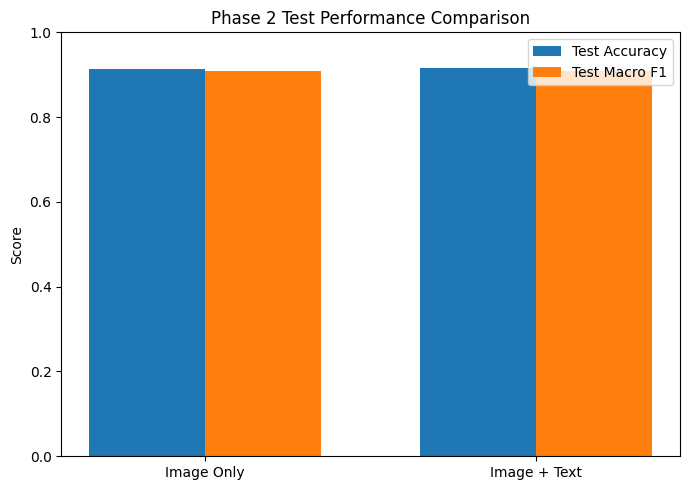

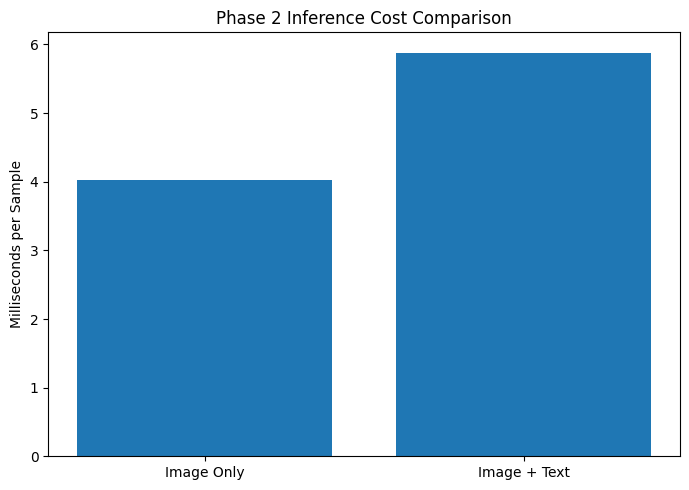

Saved figures:
phase2_test_performance_comparison.png
phase2_inference_cost_comparison.png


In [113]:

# performance and speed visualization

# Preparing values from the final comparison table
models = comparison_df["Model"].tolist()
macro_f1_values = comparison_df["Test Macro F1"].tolist()
accuracy_values = comparison_df["Test Accuracy"].tolist()
ms_per_sample_values = comparison_df["Milliseconds per Sample"].tolist()

# Performance comparison figure
plt.figure(figsize=(7, 5))
x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, accuracy_values, width, label="Test Accuracy")
plt.bar(x + width/2, macro_f1_values, width, label="Test Macro F1")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Phase 2 Test Performance Comparison")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()

plt.savefig("phase2_test_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# Inference speed comparison figure
plt.figure(figsize=(7, 5))

plt.bar(models, ms_per_sample_values)

plt.ylabel("Milliseconds per Sample")
plt.title("Phase 2 Inference Cost Comparison")
plt.tight_layout()

plt.savefig("phase2_inference_cost_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print("phase2_test_performance_comparison.png")
print("phase2_inference_cost_comparison.png")

According to the result, the "Image Only" baseline uses the checkpoint from epoch 2, while the "Image + Text" fusion model uses the checkpoint from epoch 4.

The two models achieved very similar classification performance on the test set. The "Image + Text" model achieved slightly higher test accuracy and weighted F1 score, while the "Image Only" model achieved a slightly higher macro F1 score. Since the performance differences are very small, the multimodal model does not clearly outperform the image only baseline in this Phase 2 benchmark.

According to the results related with speed check, the "Image Only" model achieved 4.02 ms/sample, while the "Image + Text" model required 5.88 ms/sample. This shows that textual descriptions provide comparable predictive performance, but they do not yet provide a clear performance gain relative to their additional inference cost.

15-Confusion Matrix

In this step, confusion matrices are generated for the best image only and image+text models on the test set.

A confusion matrix shows how predicted classes are distributed against the true classes. It is going to make it easier to identify which classes are classified correctly and which classes are confused with each other.

These figures provide a more interpretable comparison between the baseline and multimodal settings and help reveal where textual information contributes to improved classification performance.

In [114]:
labels_order_ids = sorted(id2label.keys())
labels_order_names = [id2label[i] for i in labels_order_ids]

cm_img = confusion_matrix(
    test_result_img_final["labels"],
    test_result_img_final["preds"],
    labels=labels_order_ids
)

cm_mm = confusion_matrix(
    test_result_mm_final["labels"],
    test_result_mm_final["preds"],
    labels=labels_order_ids
)

print("Image Only confusion matrix:")
print(cm_img)

print("\nImage + Text confusion matrix:")
print(cm_mm)

print("\nClass order:")
print(labels_order_names)

Image Only confusion matrix:
[[894  16  31]
 [ 59 546   3]
 [ 53   1 306]]

Image + Text confusion matrix:
[[900  19  22]
 [ 52 551   5]
 [ 62   1 297]]

Class order:
['Grass', 'Tree', 'Crop']


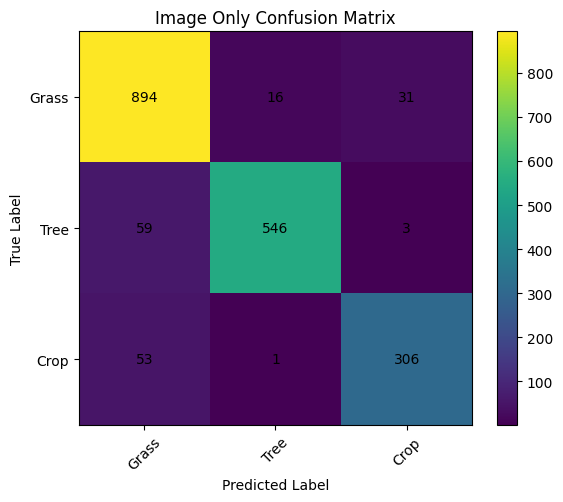

In [115]:
# Image Only confusion matrix

plt.figure(figsize=(6, 5))
plt.imshow(cm_img, interpolation="nearest")
plt.title("Image Only Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(labels_order_names))
plt.xticks(tick_marks, labels_order_names, rotation=45)
plt.yticks(tick_marks, labels_order_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_img.shape[0]):
    for j in range(cm_img.shape[1]):
        plt.text(j, i, cm_img[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("phase2_image_only_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

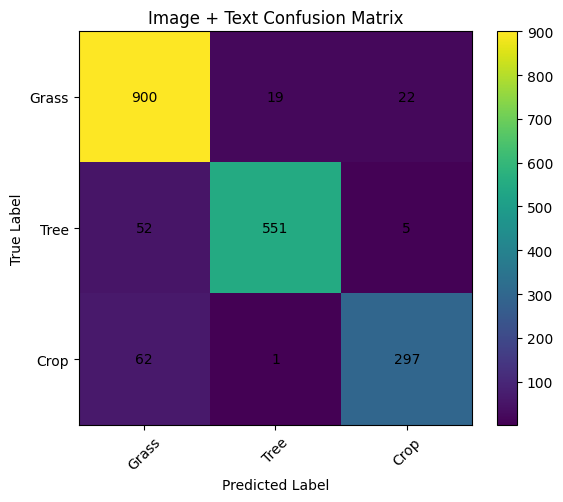

In [116]:
# Image + Text confusion matrix

plt.figure(figsize=(6, 5))
plt.imshow(cm_mm, interpolation="nearest")
plt.title("Image + Text Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(labels_order_names))
plt.xticks(tick_marks, labels_order_names, rotation=45)
plt.yticks(tick_marks, labels_order_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_mm.shape[0]):
    for j in range(cm_mm.shape[1]):
        plt.text(j, i, cm_mm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("phase2_image_text_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

The confusion matrices show that both models classify the three dominant classes with similar performance. The "Image + Text" model correctly classifies slightly more "Grass" and "Tree" samples than the "Image Only" baseline. However, it correctly classifies fewer "Crop" samples.

This explains the final metric pattern. Since macro F1 gives equal importance to each class, the lower "Crop" performance of the multimodal model reduces its macro F1 score.

In [117]:
# Class level comparison table

class_level_rows = []

for class_name in labels_order_names:
    img_report = test_result_img_final["classification_report"][class_name]
    mm_report = test_result_mm_final["classification_report"][class_name]

    class_level_rows.append({
        "Class": class_name,
        "Image Only Precision": img_report["precision"],
        "Image Only Recall": img_report["recall"],
        "Image Only F1": img_report["f1-score"],
        "Image + Text Precision": mm_report["precision"],
        "Image + Text Recall": mm_report["recall"],
        "Image + Text F1": mm_report["f1-score"],
    })

class_level_comparison_df = pd.DataFrame(class_level_rows)

display(class_level_comparison_df.round(4))

,Class,Image Only Precision,Image Only Recall,Image Only F1,Image + Text Precision,Image + Text Recall,Image + Text F1
0,Grass,0.8887,0.9501,0.9183,0.8876,0.9564,0.9207
1,Tree,0.9698,0.8980,0.9325,0.9650,0.9062,0.9347
2,Crop,0.9000,0.8500,0.8743,0.9167,0.8250,0.8684


Phase 2 addressed the using a leakage safe text column to prevent model bias on texts. Also, subset is removed and 3 class are used.

The experiments compared an "Image Only" FLAVA baseline with an "Image + Text" fusion model under the same train, validation, and test splits. The final test results show that both models achieved very similar classification performance. The "Image + Text" model produced slightly higher test accuracy and weighted F1 score, while the "Image Only" model achieved a slightly higher macro F1 score.

The inference speed comparison showed that adding text increased computational cost. Therefore, the Phase 2 results shows that textual descriptions provide comparable performance, but they do not clearly improve the image only baseline in this controlled benchmark.

In Phase 3, the full 7-class setup, class imbalance handling, text source ablation, and additional fusion strategies should be investigated to better understand when textual information can improve remote sensing image classification.